# Comparing populations with samples — why we need statistics

**The research question.** Two concert pianists both have Chopin's Ballade No. 1 in
their repertoire. Does **Pianist A** conceive of the piece as being slower than **Pianist B** does?

No two performances of the Ballade last exactly the same: tempo choices, rubato, the
acoustics of the hall, all move the duration around by tens of seconds. 

The "population" we care about is *every performance each pianist could ever give*, both those that have actually happened as well as those that each pianist would have given if they had endless opportunities to perform the piece in all possible conditions. However, we do not have access to all of these (actual and virtual) performances. We can only collect data for a **sample** of these performances: the recordings and concerts that we can actually time.

This notebook simulates a world in which **we secretly know the truth about every
performance**, so we can watch what happens when a researcher — who does *not* know the
truth — compares samples.

**Take-home message**: comparing two samples is **not** the same as comparing two populations,
and understanding the gap between the two is exactly what statistics is for.

In [8]:
# ═══ SETUP ═══  libraries, the master seed, and a consistent look for all plots
import numpy as np
import matplotlib.pyplot as plt

# One random generator for the whole simulated world
rng = np.random.default_rng(26)   # ← knob: change the seed for a different run of luck

BLUE, ORANGE = "#2a78d6", "#eb6834"   # Pianist A / Pianist B
INK, MUTED   = "#0b0b0b", "#898781"
SURFACE      = "#fcfcfb"


plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 11, "figure.dpi": 110,
})

### How this notebook is organised — and where *you* come in

Every experiment below is split into two kinds of code cells, marked by a banner in
their first line:

- **`═══ DATA GENERATION ═══`** cells build the simulated world: they set the true
  distributions, draw the samples, run the repeated studies. **All the numbers are
  decided here, and nowhere else.**
- **`═══ PLOTTING ONLY ═══`** cells just *look at* data that already exists. They never
  create or change anything, and they adapt automatically to whatever the generation
  cells produced — you never need to edit them. (A few are marked
  **`═══ INTERACTIVE PLOT ═══`**: here you can intervene to change what is being plotted.)

**Tweak the simulated world.** In the generation cells, every line tagged
`# ← knob` is a parameter you can change: true means, spreads, sample sizes, etc. To experiment:

1. edit a knob in a generation cell,
2. re-run that cell and everything below it (**to run a cell, click on the cell and press Shift+Return**), so all downstream analyses see your new world.

## 1. What does it mean to "sample from a distribution"?

Everything in this notebook — and a great deal of quantitative research — rests on a
few connected ideas, so let's meet them first.

**Some quantities are not single numbers.** *How many keys does a modern piano have?*
88 — a plain number, the same every time you ask. Now: *how long does Pianist X's
performance of Chopin's First Ballade last?* There is no single answer. It was 9:25
last month, 9:12 tonight, and next week it will be something else again. The quantity
"duration of a performance" does not *have* a value — it takes a **different value each
time the process happens**. Quantities of this kind are called **random variables**.
("Random" doesn't mean arbitrary or lawless — a 2-minute Ballade will never happen; it
means the value is settled anew, within limits, each time.)

**A random variable is described by its distribution.** Since no single number can
represent it, we describe it by saying which values are possible and how often each
tends to occur — that description is the **distribution**. For our imaginary pianist's durations
it is a bell-shaped curve centred on 540 seconds: durations near 9 minutes are common
(the curve is high there), durations of 8 or 10 minutes are rare (the curve is low
there). The distribution is the honest, complete answer to "how long does the piece
last?" — not a number, but a *shape*.

**Sampling** — or *drawing* — from the distribution means asking chance for **one
concrete value of the random variable**, with the odds weighted by the curve: values
under the high part come up often, values under the low tails come up rarely. One draw
= one performance actually happening. In code, `rng.normal(540, 30)` is exactly this —
a single roll of a (bell-shaped) die.

In [9]:
# ═══ DATA GENERATION ═══  the demo's random variable
demo_rng = np.random.default_rng(11)

demo_mean = 540   # ← knob: centre of the distribution (seconds)
demo_sd   = 30    # ← knob: spread (seconds) — how much one draw can differ from the centre

draws = [demo_rng.normal(demo_mean, demo_sd)]   # the first draw from the distribution, corresponding to one time measurement; buttons below add more

Try it yourself. Run the cell below, then:

- click **“draw 1 value”** a few times — each draw lands somewhere new, usually near
  the middle, occasionally out in a tail. The orange dot marks the latest draw;
- then click **“draw 100 values”** a few times — watch the pile of draws grow into
  the shape of the dashed curve.

In [10]:
# ═══ INTERACTIVE PLOT ═══  (the buttons append new draws to `draws` via demo_rng)
import ipywidgets as widgets

draw1_button   = widgets.Button(description="🎲  draw 1 value",
                                layout=widgets.Layout(width="150px"))
draw100_button = widgets.Button(description="🎲  draw 100 values",
                                layout=widgets.Layout(width="160px"))
demo_panel = widgets.Output()

def redraw_demo():
    k, bin_width = len(draws), demo_sd/5
    x_curve = np.linspace(demo_mean - 4 * demo_sd, demo_mean + 4 * demo_sd, 300)
    pdf = (np.exp(-0.5 * ((x_curve - demo_mean) / demo_sd) ** 2)
           / (demo_sd * np.sqrt(2 * np.pi)))
    with demo_panel:
        demo_panel.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 3.4))
        ax.hist(draws, bins=np.arange(x_curve[0], x_curve[-1], bin_width), color=BLUE,
                edgecolor=SURFACE, linewidth=0.8, label="draws so far")
        ax.plot(x_curve, pdf * k * bin_width, color=INK, linewidth=1.4,
                linestyle="--", label="the distribution (long-run shape)")
        ax.plot(draws[-1], 0, "o", color=ORANGE, markersize=9, clip_on=False,
                markeredgecolor=SURFACE, markeredgewidth=1)
        ax.set_xlabel("performance duration (s)")
        ax.set_ylabel("number of draws")
        ax.set_title(f"{k} draw{'s' if k > 1 else ''} from the distribution — "
                     f"latest: {draws[-1]:.0f} s")
        ax.legend(frameon=False)
        plt.show()
        plt.close(fig)   # tidy up: callback figures aren't closed automatically

def add_draws(m):
    draws.extend(demo_rng.normal(demo_mean, demo_sd, size=m))
    redraw_demo()

draw1_button.on_click(lambda _: add_draws(1))
draw100_button.on_click(lambda _: add_draws(100))
display(widgets.VBox([widgets.HBox([draw1_button, draw100_button]), demo_panel]))
redraw_demo()

Three lessons to take from the demo:

- **The theoretical distribution is the underlying (and unknown) truth of the process; any finite set of draws is
  a noisy snapshot of this truth.** After 5 draws the histogram looks nothing like the curve;
  after 1,000 it is very similar to it.

- In a real study you never get to see the dashed curve — **you only ever see the
  draws.** Statistics is all about trying to infer what the invisible curve might look
  like from a handful of observations.

- **This is what "quantitative" really means in research.** Almost every quantity we
  study (performance durations, listeners' ratings, notes
  correct in a sight-reading test, reaction times) is a random variable, not a fixed
  number. So the data we collect are never "the value" of anything: **a dataset is a
  sample of draws** from an underlying, unknown distribution, and a research question like *"does Pianist A take the piece
  slower than Pianist B?"* is really a question about two invisible distributions:
  *"is the centre of A's distribution higher than the centre of B's?"*. We must answer this question by lookind at draws alone.

We build random variables whose distributions *we* choose, sample from them, and see how much — or how little — the
samples reveal.

## 2. Warm-up: even measuring *one* number is not trivial

Before comparing two pianists, something much simpler: measuring a single quantity.

Twelve students are asked to time **the same studio recording** of the Ballade, each
with a stopwatch. In our simulated world we know the exact truth: the recording lasts
**540.0 seconds** (9 minutes). But every stopwatch reading is contaminated by
*measurement error* — reaction time at the start, reaction time at the end, a moment
of distraction, different decisions on what "start" and "end" means. We simulate each student's reading as

$$\text{measurement} = \text{truth} + \text{error}$$

with errors of a bit over half a second either way.

In [11]:
# ═══ DATA GENERATION ═══  twelve stopwatch readings of one fixed recording
true_duration = 540.0   # ← knob: the recording's real length (only we know this, the "experimenter" does not)
STOPWATCH_SD  = 0.6     # ← knob: typical size of the time-measurement error, in seconds
n_students    = 12      # ← knob: how many students time the recording

measurements = true_duration + rng.normal(loc=0, scale=STOPWATCH_SD, size=n_students)

print(f"The {n_students} stopwatch readings (seconds):")
print("  " + "  ".join(f"{m:.1f}" for m in measurements))
print(f"\nTruth:                    {true_duration:.2f} s")
print(f"Mean of the measurements: {measurements.mean():.2f} s")
print(f"Worst single measurement is off by {np.abs(measurements - true_duration).max():.2f} s;")
print(f"the mean is off by only {abs(measurements.mean() - true_duration):.2f} s")

The 12 stopwatch readings (seconds):
  538.8  538.2  540.7  540.9  540.8  539.7  540.0  539.8  540.8  540.5  540.0  540.4

Truth:                    540.00 s
Mean of the measurements: 540.07 s
Worst single measurement is off by 1.81 s;
the mean is off by only 0.07 s


**Collect the readings one at a time.** Run the next cell, then click
**“time the recording again”**: first you reveal the readings from above, one per
click; after that, every click produces a fresh reading. Watch the orange line — single
readings jump around, but the mean settles onto the truth.

In [12]:
# ═══ INTERACTIVE PLOT ═══  (reveals the readings above; extra clicks use a side generator)
readings = list(measurements)
extra_stopwatch = np.random.default_rng(7)   # side generator: main world untouched

shown = {"k": 1}
timer_button = widgets.Button(description="⏱  time the recording again",
                              layout=widgets.Layout(width="240px"))
timer_panel = widgets.Output()

def redraw_stopwatch():
    k = shown["k"]
    vals = np.array(readings[:k])
    with timer_panel:
        timer_panel.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 3.4))
        ax.plot(np.arange(1, k + 1), vals, "o", color=BLUE, markersize=8,
                markeredgecolor=SURFACE, markeredgewidth=1)
        ax.axhline(true_duration, color=INK, linewidth=1.2, linestyle="--")
        ax.axhline(vals.mean(), color=ORANGE, linewidth=2)
        right = max(13, k + 1)
        ax.annotate(f"truth: {true_duration:.1f} s", (right + 0.3, true_duration),
                    va="bottom", fontsize=10, color=INK,
                    xytext=(0, 5), textcoords="offset points")
        ax.annotate(f"mean: {vals.mean():.2f} s", (right + 0.3, vals.mean()),
                    va="top", fontsize=10, color=ORANGE,
                    xytext=(0, -5), textcoords="offset points")
        ax.set_xlim(0.3, right + 3.5)
        ax.set_ylim(true_duration - 4 * STOPWATCH_SD, true_duration + 4 * STOPWATCH_SD)
        ax.set_xlabel("measurement number")
        ax.set_ylabel("measured duration (s)")
        ax.set_title(f"{k} measurement{'s' if k > 1 else ''} of the same recording — "
                     f"mean is off by {abs(vals.mean() - true_duration):.2f} s")
        plt.show()
        plt.close(fig)   # tidy up: callback figures aren't closed automatically

def add_reading(_):
    shown["k"] += 1
    if shown["k"] > len(readings):                       # past the scripted readings:
        readings.append(true_duration + extra_stopwatch.normal(0, STOPWATCH_SD))
    redraw_stopwatch()

timer_button.on_click(add_reading)
display(widgets.VBox([timer_button, timer_panel]))
redraw_stopwatch()

Three things to notice — they are the seed of everything that follows:

1. **No measurement equals the truth.** Every reading = truth + error.
2. **The errors scatter in both directions**, so they partly cancel: the **mean** of
   the twelve readings is much closer to the truth than a typical single reading.
3. If the class repeated the whole exercise tomorrow, they would get twelve *new*
   readings and a *new* mean — close to 540.0 again, but not identical. **The mean
   itself is a measurement, and it too has an error** (just a smaller one).

## 3. Two performers who are *exactly* identical

First, we create a simulated world. We give each pianist a whole imagined career:
**10,000 performances** of the Ballade each, with a duration for every single one.
Crucially, both pianists draw from **the same distribution**: on average 540 seconds,
with performances varying night to night by a standard deviation of 30 seconds. They both think of the piece at the same tempo, but of course every performance differs a little.


So in this simulated world the true answer to our research question is:
**there is no difference at all between the pianists.** However, the experimenter does not know this, and has to find out by measuring a sample of performances.

In [13]:
# ═══ DATA GENERATION ═══  the two populations: every performance of each pianist
N_POP   = 10_000   # ← knob: performances per pianist — a whole imagined career
PERF_SD = 100       # ← knob: night-to-night spread of a piece durations (seconds)
MEAN_A  = 540      # ← knob: Pianist A's true mean duration (seconds)
MEAN_B  = 540      # ← knob: Pianist B's: for the time being, we set this equal to A on purpose: the two pianists have the same tempo in mind on average

def make_performer(mean_seconds):
    """All the durations (in seconds) of one pianist's possible performances."""
    return rng.normal(loc=mean_seconds, scale=PERF_SD, size=N_POP)

pianist_A = make_performer(MEAN_A)
pianist_B = make_performer(MEAN_B)

print(f"True mean duration, Pianist A: {pianist_A.mean():6.1f} s")
print(f"True mean duration, Pianist B: {pianist_B.mean():6.1f} s")
print(f"True difference:               {pianist_A.mean() - pianist_B.mean():6.1f} s")

True mean duration, Pianist A:  541.0 s
True mean duration, Pianist B:  539.2 s
True difference:                  1.8 s


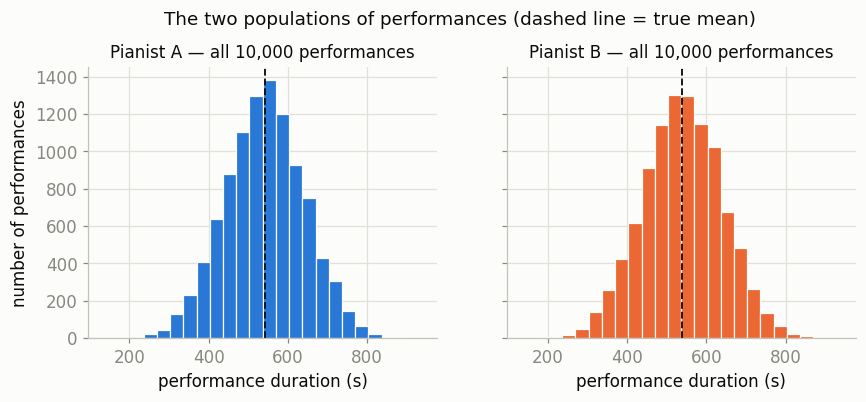

In [14]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharex=True, sharey=True)
lo = min(pianist_A.min(), pianist_B.min())
hi = max(pianist_A.max(), pianist_B.max())
bins = np.arange(lo, hi + 10, PERF_SD/3)          # 10-second bins covering all the data

for ax, perf, name, color in [(axes[0], pianist_A, "Pianist A", BLUE),
                              (axes[1], pianist_B, "Pianist B", ORANGE)]:
    ax.hist(perf, bins=bins, color=color, edgecolor=SURFACE, linewidth=0.8)
    ax.axvline(perf.mean(), color=INK, linewidth=1.2, linestyle="--")
    ax.set_title(f"{name} — all {len(perf):,} performances", fontsize=11)
    ax.set_xlabel("performance duration (s)")

axes[0].set_ylabel("number of performances")
fig.suptitle("The two populations of performances (dashed line = true mean)",
             y=1.04, fontsize=12)
plt.show()

The two histograms are, for all practical purposes, the same picture. Of course:
we built them that way! 

## 4. One study: time 15 performances of each pianist

A real researcher cannot see the histograms above (i.e., they do not have access to thousands of performances). They collect what they can get hold
of: say, **15 randomly chosen performances of each pianist** (live recordings, concert
timings). The experimenter proceeds to time these 15 performances for each pianist. This is a sample from the two distributions above.

In [15]:
# ═══ DATA GENERATION ═══  one study: two samples of performances, one for pianist A and one for pianist B
n = 15   # ← knob: performances timed per pianist

sample_A = rng.choice(pianist_A, size=n, replace=False)
sample_B = rng.choice(pianist_B, size=n, replace=False)

diff_observed = sample_A.mean() - sample_B.mean()

print(f"Sample mean, Pianist A ({n} performances): {sample_A.mean():6.1f} s")
print(f"Sample mean, Pianist B ({n} performances): {sample_B.mean():6.1f} s")
print(f"Observed difference:                       {diff_observed:+6.1f} s")

Sample mean, Pianist A (15 performances):  591.1 s
Sample mean, Pianist B (15 performances):  544.1 s
Observed difference:                        +47.0 s


**Now watch the study unfold as the performances are measured one at a time.** Run the next cell and
click **“time +1 performance of each”**. The black bars are the running sample means —
see how they wander as each new timing arrives, and where they happen to stop when your
supply of recordings runs out.

In [16]:
# ═══ INTERACTIVE PLOT ═══  (reveals the two samples above one timing at a time)
jitter_A = rng.uniform(-0.08, 0.08, size=n)   # spread the dots out a little
jitter_B = rng.uniform(-0.08, 0.08, size=n)

surveyed = {"k": 1}
survey_button = widgets.Button(description="🎹  time +1 performance of each",
                               layout=widgets.Layout(width="260px"))
survey_panel = widgets.Output()

def redraw_study():
    k = surveyed["k"]
    with survey_panel:
        survey_panel.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 3.6))
        for x, sample, jitter, color in [(0, sample_A, jitter_A, BLUE),
                                         (1, sample_B, jitter_B, ORANGE)]:
            ax.plot(x + jitter[:k], sample[:k], "o", color=color, markersize=7,
                    markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.9)
            ax.hlines(sample[:k].mean(), x - 0.18, x + 0.18, color=INK, linewidth=2)
            ax.annotate(f"mean {sample[:k].mean():.0f} s", (x + 0.22, sample[:k].mean()),
                        va="center", fontsize=10, color=INK)
        ax.set_xticks([0, 1], ["Pianist A", "Pianist B"])
        ax.set_xlim(-0.6, 1.8)
        ax.set_ylim(min(sample_A.min(), sample_B.min()) - 10,
                    max(sample_A.max(), sample_B.max()) + 10)
        ax.set_ylabel("performance duration (s)")
        diff_so_far = sample_A[:k].mean() - sample_B[:k].mean()
        ax.set_title(f"{k} of {n} performances timed per pianist — "
                     f"difference so far: {diff_so_far:+.1f} s")
        plt.show()
        plt.close(fig)   # tidy up: callback figures aren't closed automatically

def add_student(_):
    surveyed["k"] = min(surveyed["k"] + 1, n)
    if surveyed["k"] == n:
        survey_button.disabled = True
        survey_button.description = f"study complete (n = {n})"
    redraw_study()

survey_button.on_click(add_student)
display(widgets.VBox([survey_button, survey_panel]))
redraw_study()

**The samples differ!** We could already write the headline:

> *"Study finds Pianist A takes the Ballade markedly slower/faster than Pianist B."*

But *we* know the two pianists are identical. The difference above is produced by
**sampling luck** alone — which 15 performances we actually measured out of all those that did or may have happened.

This is the core problem: **a difference between samples is not evidence, by itself,
of a difference between populations.** So how big does a difference have to be before
we take it seriously? To answer that, let's do something no real researcher can do:
repeat the entire study a thousand times.

## 5. Repeat the study 1,000 times

Same world (identical pianists), same method (15 performances of each). Each repetition
gives one "observed difference". We collect all 1,000 of them.

In [17]:
# ═══ DATA GENERATION ═══  1,000 repetitions of the whole study
def one_study(pop_1, pop_2, n):
    """Time n performances from each population; return the difference in sample means."""
    s1 = rng.choice(pop_1, size=n, replace=False)
    s2 = rng.choice(pop_2, size=n, replace=False)
    return s1.mean() - s2.mean()

n_studies = 1_000   # ← knob: how many times the study is repeated

diffs = np.array([one_study(pianist_A, pianist_B, n) for _ in range(n_studies)])

as_large = np.mean(np.abs(diffs) >= abs(diff_observed)) * 100
print(f"Largest difference found by pure chance: {np.abs(diffs).max():.1f} s")
print(f"Studies with a difference at least as large as ours ({abs(diff_observed):.1f} s): "
      f"{as_large:.0f}%")

Largest difference found by pure chance: 122.6 s
Studies with a difference at least as large as ours (47.0 s): 20%


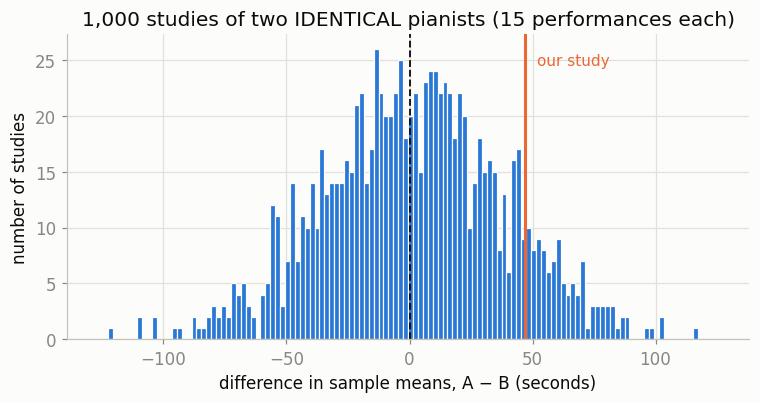

In [18]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, ax = plt.subplots(figsize=(8, 3.6))

span = np.abs(diffs).max() + 4
ax.hist(diffs, bins=np.arange(-span, span, 2), color=BLUE,
        edgecolor=SURFACE, linewidth=0.8)
ax.axvline(0, color=INK, linewidth=1.2, linestyle="--")
ax.axvline(diff_observed, color=ORANGE, linewidth=2)
ax.annotate("our study", (diff_observed, ax.get_ylim()[1] * 0.9),
            color=ORANGE, fontsize=10,
            ha="left" if diff_observed >= 0 else "right",
            xytext=(8 if diff_observed >= 0 else -8, 0), textcoords="offset points")

ax.set_xlabel("difference in sample means, A − B (seconds)")
ax.set_ylabel("number of studies")
ax.set_title(f"{n_studies:,} studies of two IDENTICAL pianists ({n} performances each)")
plt.show()

Every one of those 1,000 differences is pure chance — the true difference is zero.
And yet single studies routinely "find" differences of ten, twenty, even thirty seconds.

This histogram is the most important object in this course. It shows **what chance
alone can produce** — statisticians call it the *sampling distribution of the
difference* (here, under the assumption of no real difference: the *null
distribution*). Judging a study result means asking: **where does it fall on this
histogram?** A result that chance produces all the time proves nothing; a result far
out in the tails is *surprising* — and surprise is where evidence begins.

## 6. Bigger samples tame the luck

Chance never disappears, but it shrinks as samples grow. Same experiment — 1,000
studies of the two identical pianists — with increasing sample sizes. (No pianist
performs one piece 1,000 times for our convenience, but simulation is cheap.)

In [19]:
# ═══ DATA GENERATION ═══  the same 1,000 studies, at several sample sizes
sample_sizes = [10, 50, 200, 1000]   # ← knob: try other sizes (max: N_POP)

diffs_by_size = {size: np.array([one_study(pianist_A, pianist_B, size)
                                 for _ in range(n_studies)])
                 for size in sample_sizes}

for size in sample_sizes:
    print(f"n = {size:4d}:  chance differences span "
          f"±{np.abs(diffs_by_size[size]).max():5.1f} s")

n =   10:  chance differences span ±151.0 s
n =   50:  chance differences span ± 75.6 s
n =  200:  chance differences span ± 42.9 s
n = 1000:  chance differences span ± 19.6 s


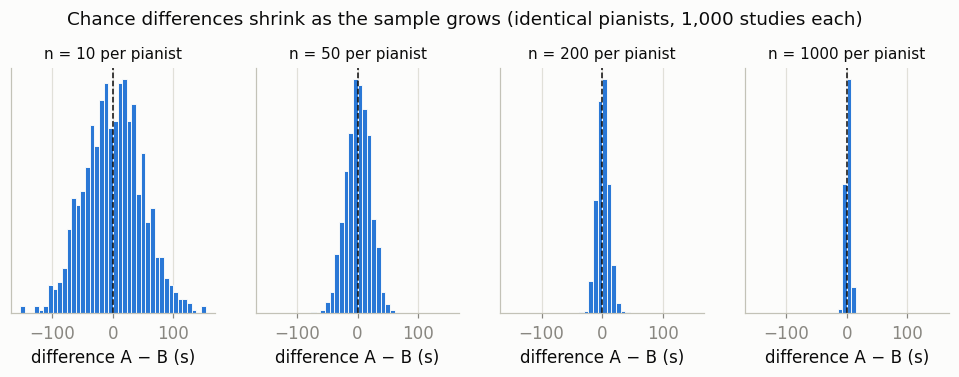

In [20]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, axes = plt.subplots(1, len(sample_sizes), figsize=(11, 2.9),
                         sharex=True, sharey=False)

span = max(np.abs(d).max() for d in diffs_by_size.values()) + 2
bins = np.linspace(-span, span, 41)

for ax, size in zip(axes, sample_sizes):
    ax.hist(diffs_by_size[size], bins=bins, color=BLUE,
            edgecolor=SURFACE, linewidth=0.6)
    ax.axvline(0, color=INK, linewidth=1, linestyle="--")
    ax.set_title(f"n = {size} per pianist", fontsize=10)
    ax.set_yticks([])
    ax.set_xlabel("difference A − B (s)")

fig.suptitle("Chance differences shrink as the sample grows (identical pianists, "
             f"{n_studies:,} studies each)", y=1.06, fontsize=12)
plt.show()

If we only measure 10 performances per pianist, chance often produces differences of ±20
seconds. With 1,000, we rarely find difference larger than ±2. The spread of these histograms is what
statisticians call the **standard error**, and it shrinks with the *square root* of the
sample size: to make luck half as strong you need **four times** as many performances.

If we only have 10 measurements, a difference of ±10s might happen by chance even if the "true" means are identical. By contrast, if we collect thousands of measurements and we still observe the same ±10s difference, it is very unlikely to be caused by chance (rather, we would conclude that the two piansts conceive of the ballad at genuinely different tempos).

## 7. What if there *is* a real difference?

Now we simulate a different world. We introduce **Pianist C**, who really does think of the Ballade as being slower: 555 seconds on average against Pianist A's 540 — a genuine difference of
**15 seconds**. First, look at the two populations:

In [21]:
# ═══ DATA GENERATION ═══  a third pianist who is genuinely slower
MEAN_C = 555   # ← knob: Pianist C's true mean duration (seconds)

pianist_C = make_performer(MEAN_C)

print(f"True mean duration, Pianist A: {pianist_A.mean():6.1f} s")
print(f"True mean duration, Pianist C: {pianist_C.mean():6.1f} s")
print(f"True difference (C − A):       {MEAN_C - MEAN_A:+6.1f} s  (by construction)")

True mean duration, Pianist A:  541.0 s
True mean duration, Pianist C:  556.3 s
True difference (C − A):        +15.0 s  (by construction)


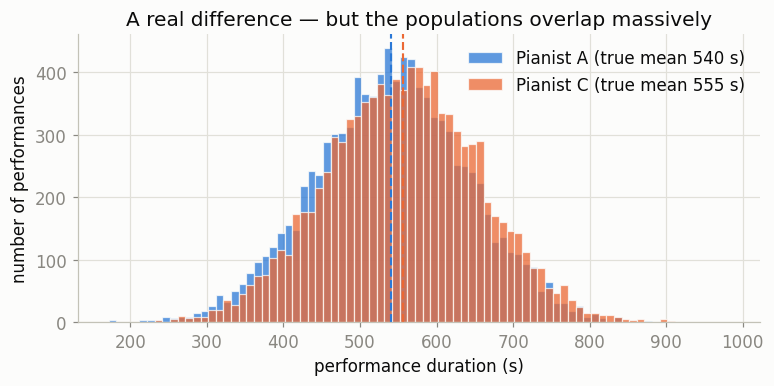

In [22]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, ax = plt.subplots(figsize=(8, 3.4))
lo = min(pianist_A.min(), pianist_C.min())
hi = max(pianist_A.max(), pianist_C.max())
bins = np.arange(lo, hi + 10, 10)

ax.hist(pianist_A, bins=bins, color=BLUE, alpha=0.75, edgecolor=SURFACE,
        linewidth=0.8, label=f"Pianist A (true mean {MEAN_A} s)")
ax.hist(pianist_C, bins=bins, color=ORANGE, alpha=0.75, edgecolor=SURFACE,
        linewidth=0.8, label=f"Pianist C (true mean {MEAN_C} s)")
ax.axvline(pianist_A.mean(), color=BLUE, linewidth=1.4, linestyle="--")
ax.axvline(pianist_C.mean(), color=ORANGE, linewidth=1.4, linestyle="--")

ax.set_xlabel("performance duration (s)")
ax.set_ylabel("number of performances")
ax.set_title("A real difference — but the populations overlap massively")
ax.legend(frameon=False)
plt.show()

The difference is real, but the histograms overlap almost entirely — the brownish
region is where blue and orange sit on top of each other: on plenty of nights,
Pianist C is *faster* than a typical Pianist A performance. What does a small study
see in this world?

In [23]:
# ═══ DATA GENERATION ═══  1,000 studies comparing C with A
diffs_real = np.array([one_study(pianist_C, pianist_A, n) for _ in range(n_studies)])

wrong_direction = np.mean(diffs_real <= 0) * 100
print(f"True difference (C − A): {MEAN_C - MEAN_A:+.1f} s")
print(f"With n = {n} per pianist, across {n_studies:,} studies:")
print(f"  smallest observed difference: {diffs_real.min():+6.1f} s")
print(f"  largest observed difference:  {diffs_real.max():+6.1f} s")
print(f"  studies pointing the WRONG way (A appears slower): {wrong_direction:.0f}%")

True difference (C − A): +15.0 s
With n = 15 per pianist, across 1,000 studies:
  smallest observed difference: -114.4 s
  largest observed difference:  +127.0 s
  studies pointing the WRONG way (A appears slower): 33%


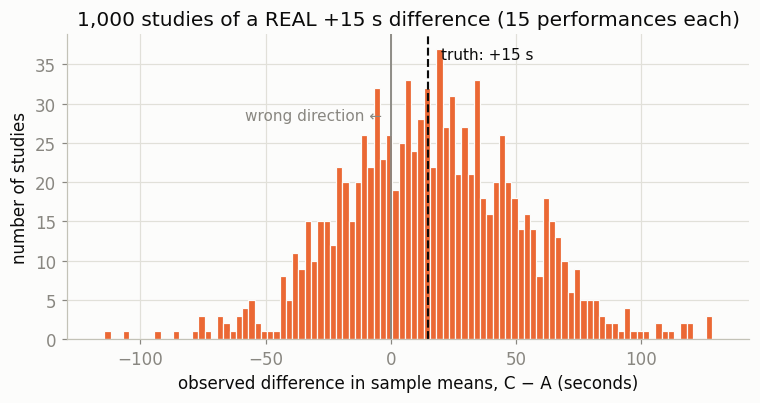

In [24]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, ax = plt.subplots(figsize=(8, 3.6))

true_gap = MEAN_C - MEAN_A
ax.hist(diffs_real, bins=np.arange(diffs_real.min() - 2.5, diffs_real.max() + 5, 2.5),
        color=ORANGE, edgecolor=SURFACE, linewidth=0.8)
ax.axvline(true_gap, color=INK, linewidth=1.4, linestyle="--")
ax.annotate(f"truth: {true_gap:+.0f} s", (true_gap, ax.get_ylim()[1] * 0.92),
            color=INK, fontsize=10, xytext=(8, 0), textcoords="offset points")
ax.axvline(0, color=MUTED, linewidth=1.2)
ax.annotate("wrong direction ←", (0, ax.get_ylim()[1] * 0.72), color=MUTED,
            fontsize=10, ha="right", xytext=(-6, 0), textcoords="offset points")

ax.set_xlabel("observed difference in sample means, C − A (seconds)")
ax.set_ylabel("number of studies")
ax.set_title(f"{n_studies:,} studies of a REAL {true_gap:+.0f} s difference "
             f"({n} performances each)")
plt.show()

Even though Pianist C *really* averages 15 seconds slower, a study with 15
performances of each sometimes measures the difference as +40 seconds, sometimes as
roughly zero — and a non-trivial share of studies point in the **wrong direction**
entirely.

How quickly does a bigger sample fix this?

In [25]:
# ═══ DATA GENERATION ═══  chance of a wrong-way result, at several sample sizes
sizes = np.array([5, 10, 20, 50, 100, 200])   # ← knob: sample sizes to test

p_wrong = []
for size in sizes:
    d = np.array([one_study(pianist_C, pianist_A, size) for _ in range(n_studies)])
    p_wrong.append(np.mean(d <= 0) * 100)

for size, p in zip(sizes, p_wrong):
    print(f"n = {size:3d}:  {p:4.1f}% of studies point the wrong way")

n =   5:  39.8% of studies point the wrong way
n =  10:  37.0% of studies point the wrong way
n =  20:  29.0% of studies point the wrong way
n =  50:  24.2% of studies point the wrong way
n = 100:  13.7% of studies point the wrong way
n = 200:   4.8% of studies point the wrong way


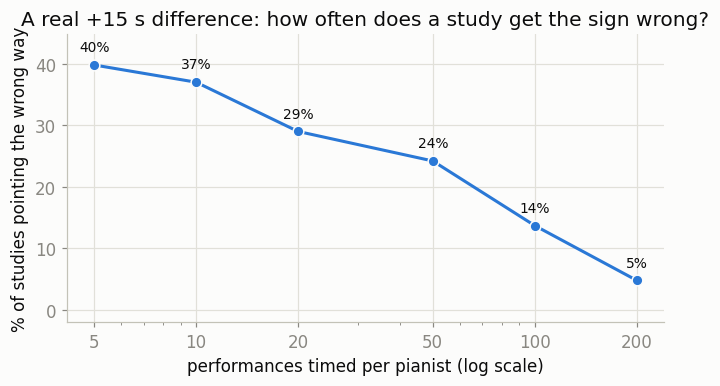

In [26]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sizes, p_wrong, "-o", color=BLUE, linewidth=2, markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1)
ax.set_ylim(-2, max(p_wrong) + 5)   # headroom for the labels
for x, y in zip(sizes, p_wrong):
    ax.annotate(f"{y:.0f}%", (x, y), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9, color=INK)

ax.set_xscale("log")
ax.set_xticks(sizes, [str(s) for s in sizes])
ax.set_xlabel("performances timed per pianist (log scale)")
ax.set_ylabel("% of studies pointing the wrong way")
ax.set_title(f"A real {MEAN_C - MEAN_A:+.0f} s difference: "
             "how often does a study get the sign wrong?")
plt.show()

## 8. So *this* is why we need statistics

The warm-up and the two simulated worlds each carry one lesson:

- **Every measurement = truth + error** — and averaging shrinks the error but never
  removes it. A sample mean is a measurement of a population mean.
- **Identical populations** still produce different samples — so an observed
  difference, by itself, proves nothing.
- **Genuinely different populations** can produce samples that understate, exaggerate,
  or even reverse the true difference — so a single comparison can mislead in every
  direction.

Statistics is the discipline of reasoning honestly in this situation. The tools you
will meet later in this course are all answers to questions this notebook raised:

| The question raised here | The statistical tool |
|---|---|
| What produces the numbers we observe? | a **random variable** and its **distribution**, glimpsed through draws (Section 1) |
| How wrong is a single measurement likely to be? | **measurement error** models (Section 2) |
| How much does chance move a sample mean around? | **standard error** |
| What differences would chance alone produce? | the **null distribution** (Section 5's histogram) |
| Is *our* difference surprising under chance alone? | the **p-value** / significance test |
| What range of true differences is compatible with our data? | the **confidence interval** |
| How many performances must we time to trust the answer? | **power analysis** / sample-size planning |

**Things to try** — every experiment below is one knob in a `═══ DATA GENERATION ═══`
cell; edit it, then *Run → Run Selected Cell and All Below*:

1. Section 2: give the students a worse stopwatch technique — set `STOPWATCH_SD = 2`.
   How far off can a single reading — and the mean — now be?
2. Section 4: set `n = 5`, then `n = 500`. How do the headline and Section 5's
   histogram change?
3. Section 7: set `MEAN_C = 545` (a small real effect of just 5 seconds). How many
   performances do you now need before most studies point the right way?
4. Section 3: set `PERF_SD = 10` — pianists who are very consistent night to night.
   Why do real differences now show up so much more easily? (This is why controlling
   unwanted variation is worth so much in experimental design.)
5. Setup cell: change the seed — different luck, same lessons.